In [1]:

# DECISION TREE CLASSIFICATION — TITANIC DATASET
# Topic: Predicting whether a passenger survived the Titanic
# Dataset: titanic.csv  ->  Pclass, Sex, Age, SibSp, Parch, Fare, Embarked -> Survived



# 1. Import the necessary Python libraries

# pandas is used for creating and working with tables/dataframes
import pandas as pd

# train_test_split is used to divide the data into training and testing sets
from sklearn.model_selection import train_test_split

# DecisionTreeClassifier is the machine learning model we are using
from sklearn.tree import DecisionTreeClassifier

# plot_tree is used to visualize the decision tree
from sklearn.tree import plot_tree

# These are used to evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# matplotlib is used for plotting charts and visualizations
import matplotlib.pyplot as plt

In [2]:
# 2. Load the dataset from the CSV file

# We read the titanic.csv file using pandas.
# The target variable is Survived.
# 1 means the passenger survived.
# 0 means the passenger did not survive.

df = pd.read_csv("titanic.csv")

print("=== Original Dataset (first 10 rows) ===")
display(df.head(10))

=== Original Dataset (first 10 rows) ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
# 3. Check basic information about the dataset

print("\n=== Dataset Shape ===")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

print("\n=== Dataset Information ===")
print(df.info())

print("\n=== Summary of Dataset ===")
print(df.describe(include="all"))


=== Dataset Shape ===
Rows: 891 | Columns: 12

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

=== Summary of Dataset ===
        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000              

In [4]:
# 4. Check the target variable distribution

# This tells us how many records belong to each class.
# Class 0 = did NOT survive
# Class 1 = survived

print("\n=== Target Variable Distribution ===")
print(df["Survived"].value_counts())

print("\n=== Missing Values Per Column ===")
print(df.isnull().sum())


=== Target Variable Distribution ===
Survived
0    549
1    342
Name: count, dtype: int64

=== Missing Values Per Column ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# 4b. Clean the dataset — handle missing values
# ------------------------------------------------------------
# The Titanic dataset has missing values in three columns:
#
# Age     -> 177 missing values  -> fill with the median age
# Cabin   -> 687 missing values  -> too many missing, drop the column
# Embarked ->  2 missing values  -> fill with the most common port (mode)
#
# We also drop columns that are not useful for prediction:
# PassengerId, Name, Ticket — these are unique identifiers, not patterns.

# Fill Age with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with the mode (most common value)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop columns we will not use
df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], inplace=True)

print("=== Dataset after cleaning ===")
display(df.head(10))

print("\n=== Missing values after cleaning ===")
print(df.isnull().sum())

=== Dataset after cleaning ===


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,28.0,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C



=== Missing values after cleaning ===
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [6]:
# 5. Separate the input features and target variable

# X contains the independent variables/features.
# y contains the dependent variable/target.

X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]

y = df["Survived"]

print("\n=== Input Features X ===")
display(X.head())

print("\n=== Target Variable y ===")
display(y.head())


=== Input Features X ===


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S



=== Target Variable y ===


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [7]:
# 6. Convert categorical variables into numeric form
# ------------------------------------------------------------
# Machine learning models cannot directly understand text values like:
# "male", "female", "S", "C", "Q".
#
# Therefore, we convert them into numerical columns using one-hot encoding.
#
# Example:
# Sex_male becomes 1 if the passenger is male, otherwise 0.
# Embarked_S becomes 1 if the passenger boarded at Southampton, otherwise 0.

X_encoded = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=False)

print("\n=== Encoded Input Features ===")
display(X_encoded.head())

print("\n=== Encoded Column Names ===")
print(list(X_encoded.columns))


=== Encoded Input Features ===


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,False,True,False,False,True
1,1,38.0,1,0,71.2833,True,False,True,False,False
2,3,26.0,0,0,7.9250,True,False,False,False,True
3,1,35.0,1,0,53.1000,True,False,False,False,True
4,3,35.0,0,0,8.0500,False,True,False,False,True



=== Encoded Column Names ===
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


In [8]:
# 7. Split the dataset into training and testing sets
# ------------------------------------------------------------
# Training set: used to train the model.
# Testing set: used to check how well the model performs on unseen data.
#
# We use 25% of the data for testing.

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.25,
    random_state=42
)

print("Training set size:", X_train.shape[0], "rows")
print("Testing set size: ", X_test.shape[0], "rows")

print("\n=== Training Features (first 5 rows) ===")
display(X_train.head())

print("\n=== Testing Features (first 5 rows) ===")
display(X_test.head())

Training set size: 668 rows
Testing set size:  223 rows

=== Training Features (first 5 rows) ===


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
298,1,28.00,0,0,30.5000,False,True,False,False,True
884,3,25.00,0,0,7.0500,False,True,False,False,True
247,2,24.00,0,2,14.5000,True,False,False,False,True
478,3,22.00,0,0,7.5208,False,True,False,False,True
305,1,0.92,1,2,151.5500,False,True,False,False,True



=== Testing Features (first 5 rows) ===


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
709,3,28.0,1,1,15.2458,False,True,True,False,False
439,2,31.0,0,0,10.5000,False,True,False,False,True
840,3,20.0,0,0,7.9250,False,True,False,False,True
720,2,6.0,0,1,33.0000,True,False,False,False,True
39,3,14.0,1,0,11.2417,True,False,True,False,False


In [9]:
# 8. Create the Decision Tree Classifier model
# ------------------------------------------------------------
# criterion="entropy" means the tree will use information gain.
# You can also use criterion="gini".
#
# max_depth=3 limits the tree depth so that the tree is easier to visualize.

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

In [13]:
 #9. Train the model

# The model learns patterns from the training data.

model.fit(X_train, y_train)

print("\nDecision Tree model has been trained successfully.")


Decision Tree model has been trained successfully.


In [14]:
# 10. Make predictions using the test data

y_pred = model.predict(X_test)

print("\n=== Actual Values (first 10) ===")
print(list(y_test[:10]))

print("\n=== Predicted Values (first 10) ===")
print(list(y_pred[:10]))


=== Actual Values (first 10) ===
[1, 0, 0, 1, 1, 1, 1, 0, 1, 1]

=== Predicted Values (first 10) ===
[0, 0, 0, 1, 1, 1, 1, 0, 1, 1]


In [15]:
# 11. Evaluate the model

# Accuracy shows the percentage of correct predictions.

accuracy = accuracy_score(y_test, y_pred)

print("\n=== Model Accuracy ===")
print(round(accuracy * 100, 2), "%")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Did Not Survive", "Survived"]))


=== Model Accuracy ===
80.27 %

=== Confusion Matrix ===
[[117  17]
 [ 27  62]]

=== Classification Report ===
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.87      0.84       134
       Survived       0.78      0.70      0.74        89

       accuracy                           0.80       223
      macro avg       0.80      0.78      0.79       223
   weighted avg       0.80      0.80      0.80       223



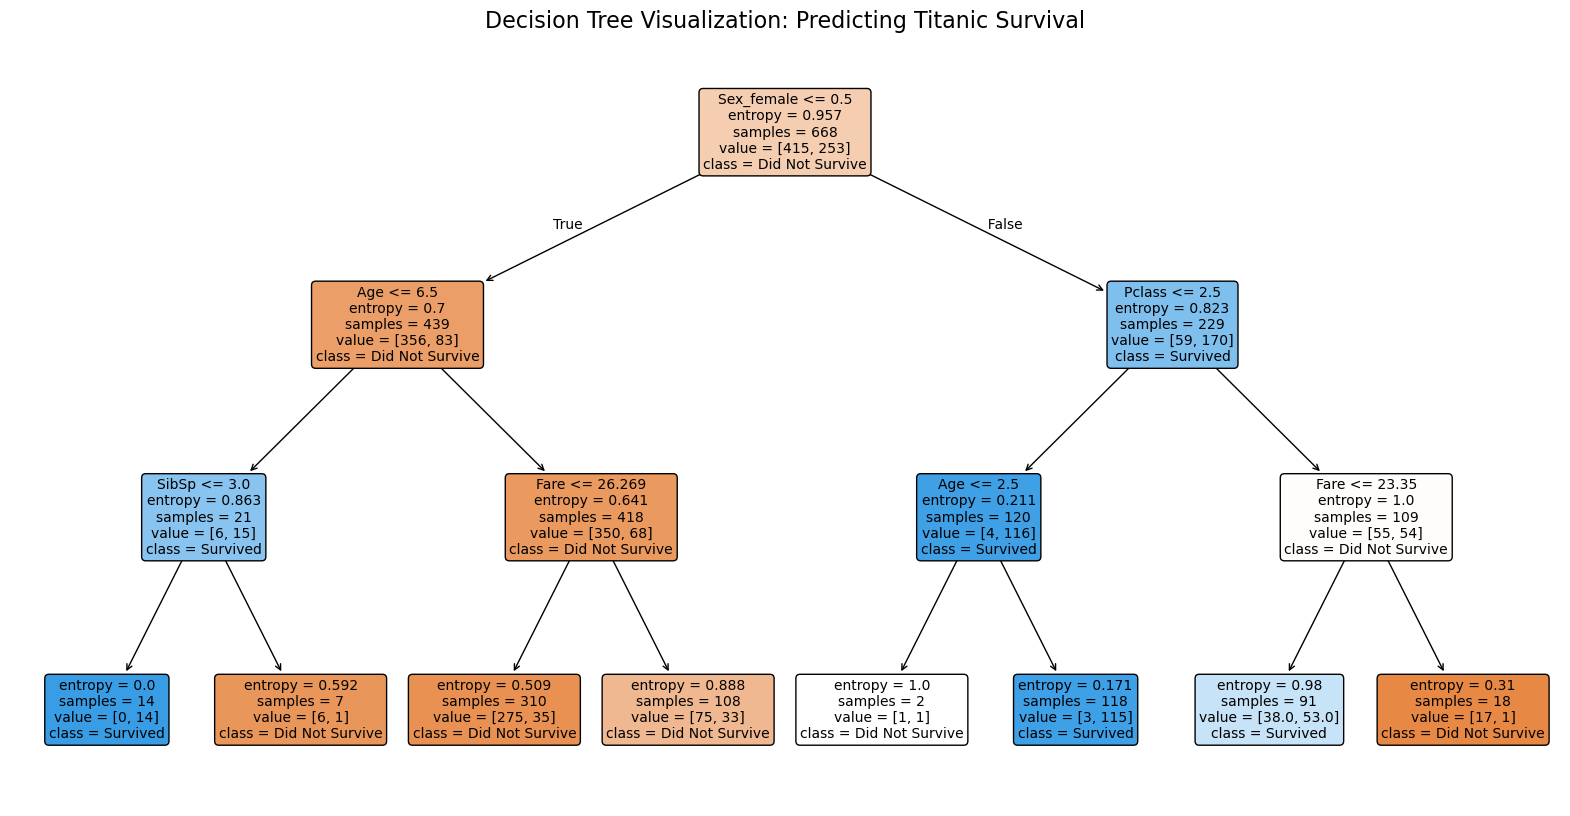

In [16]:
# 12. Visualize the Decision Tree

# This shows how the decision tree makes decisions.
# Each node shows a question that splits the data.
# The final leaves show the predicted class.

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X_encoded.columns,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Visualization: Predicting Titanic Survival", fontsize=16)
plt.show()

In [17]:
# 13. Make prediction for a new passenger
# ------------------------------------------------------------
# Let us predict whether a 29-year-old female in 1st class
# who boarded at Cherbourg (C) survived.

new_passenger = pd.DataFrame({
    "Pclass":   [1],
    "Sex":      ["female"],
    "Age":      [29],
    "SibSp":    [0],
    "Parch":    [0],
    "Fare":     [75.0],
    "Embarked": ["C"]
})

print("\n=== New Passenger Data ===")
display(new_passenger)


=== New Passenger Data ===


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,female,29,0,0,75.0,C


In [18]:
# 14. Encode the new passenger data

# The new data must have the same encoded columns as the training data.
# Therefore, we use reindex to match the columns.

new_passenger_encoded = pd.get_dummies(new_passenger, columns=["Sex", "Embarked"], drop_first=False)

new_passenger_encoded = new_passenger_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

print("\n=== Encoded New Passenger Data ===")
display(new_passenger_encoded)


=== Encoded New Passenger Data ===


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,29,0,0,75.0,True,0,True,0,0


In [19]:
# 15. Predict survival for the new passenger

new_prediction = model.predict(new_passenger_encoded)

print("\n=== Prediction for New Passenger ===")

if new_prediction[0] == 1:
    print("The model predicts that this passenger SURVIVED.")
else:
    print("The model predicts that this passenger did NOT survive.")


=== Prediction for New Passenger ===
The model predicts that this passenger SURVIVED.


In [20]:
# Class 1 = Survived
new_prediction_probability = model.predict_proba(new_passenger_encoded)

print("\n=== Prediction Probability ===")
print("Probability of NOT Surviving:", round(new_prediction_probability[0][0], 4))
print("Probability of Surviving:    ", round(new_prediction_probability[0][1], 4))


print("\n=== FINAL RESULT INTERPRETATION ===")
print("""
In this example, we used a Decision Tree Classifier to predict whether
a Titanic passenger survived.

The model used seven input features:

1. Pclass   — passenger class (1st, 2nd, or 3rd)
2. Sex      — male or female
3. Age      — age in years
4. SibSp    — number of siblings/spouses aboard
5. Parch    — number of parents/children aboard
6. Fare     — ticket price
7. Embarked — port of boarding (C = Cherbourg, Q = Queenstown, S = Southampton)

The target variable was Survived:
  0 = Did NOT survive
  1 = Survived

Unlike the salaries dataset, the Titanic dataset has:
  - 891 real passengers (not 16 hardcoded rows)
  - Missing values that required cleaning before training
  - A mix of numeric and categorical features
  - A genuinely different result every time you change the split or features
""")


=== Prediction Probability ===
Probability of NOT Surviving: 0.0254
Probability of Surviving:     0.9746

=== FINAL RESULT INTERPRETATION ===

In this example, we used a Decision Tree Classifier to predict whether
a Titanic passenger survived.

The model used seven input features:

1. Pclass   — passenger class (1st, 2nd, or 3rd)
2. Sex      — male or female
3. Age      — age in years
4. SibSp    — number of siblings/spouses aboard
5. Parch    — number of parents/children aboard
6. Fare     — ticket price
7. Embarked — port of boarding (C = Cherbourg, Q = Queenstown, S = Southampton)

The target variable was Survived:
  0 = Did NOT survive
  1 = Survived

Unlike the salaries dataset, the Titanic dataset has:
  - 891 real passengers (not 16 hardcoded rows)
  - Missing values that required cleaning before training
  - A mix of numeric and categorical features
  - A genuinely different result every time you change the split or features

